# Chapter 1 — Sampling and Data

How we get data, and why the way we sample decides what we can conclude.

| Section | What it covers |
|---|---|
| 1.1 | Population and sample |
| 1.2 | Sampling methods and bias |
| 1.3 | Variation in samples |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [Sampling and Data](https://khh-aka-lucifer.github.io/statLab/chapters/sampling-and-data/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## Meet the penguins

Three hundred and forty-four penguins were measured at Palmer Station, Antarctica, between 2007
and 2009. Researchers weighed them, measured the bill and the flipper, and noted the species,
the island and the sex.

We are going to treat these 344 birds as an entire **population**. That is a luxury. In real work
you almost never get to see the whole population, which is the whole reason statistics exists.
Here we can see it, which means we can check our answers, and that makes it a good place to learn.

In [2]:
penguins = pd.read_csv(DATA / "penguins.csv")

print(penguins.shape)
penguins.head()

(344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


Before anything else, look for holes. Real data has them, and a value that is quietly missing will
happily poison a mean without telling you.

In [3]:
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Two penguins were never weighed and eleven have no recorded sex. That is not a mistake in the file,
it is what field work looks like. Two out of 344 is small, so for body mass we will simply work with
the 342 birds that have a weight, and say so out loud rather than letting pandas drop them silently.

In [4]:
mass = penguins["body_mass_g"].dropna()

print(f"weighed: {len(mass)} of {len(penguins)} penguins")
print(f"population mean  mu = {mass.mean():.1f} g")
print(f"population sd  sigma = {mass.std(ddof=0):.1f} g")

weighed: 342 of 344 penguins
population mean  mu = 4201.8 g
population sd  sigma = 800.8 g


## 1.1 Population and sample

A **population** is every member of the group you care about. A **sample** is the handful you
actually measure. A number computed from the population is a **parameter** and gets a Greek letter,
so the population mean is $\mu$. The same number computed from a sample is a **statistic** and gets
a Latin letter, so the sample mean is $\bar{x}$.

We know $\mu = 4201.8$ g because we can see all 342 weighed penguins. Now let us pretend we cannot,
and go out and catch thirty.

In [5]:
sample = penguins.dropna(subset=["body_mass_g"]).sample(30, random_state=1)

print(f"sample mean   xbar = {sample['body_mass_g'].mean():.1f} g")
print(f"population    mu   = {mass.mean():.1f} g")
print(f"we were off by     {sample['body_mass_g'].mean() - mass.mean():+.1f} g")

sample mean   xbar = 4422.5 g
population    mu   = 4201.8 g
we were off by     +220.7 g


Close, but not right. Now catch a different thirty.

In [6]:
for seed in [1, 2, 3, 4, 5]:
    s = penguins.dropna(subset=["body_mass_g"]).sample(30, random_state=seed)
    print(f"seed {seed}:  xbar = {s['body_mass_g'].mean():7.1f} g   error = {s['body_mass_g'].mean() - mass.mean():+7.1f} g")

seed 1:  xbar =  4422.5 g   error =  +220.7 g
seed 2:  xbar =  4116.7 g   error =   -85.1 g
seed 3:  xbar =  4446.7 g   error =  +244.9 g
seed 4:  xbar =  4159.2 g   error =   -42.6 g
seed 5:  xbar =  4544.2 g   error =  +342.4 g


Five honest samples, five different answers, none of them exactly $\mu$. Nobody made a mistake. This
is **sampling variability**, and it is the thing the rest of the course is about.

Here is the same picture the website draws in section 1.1. Every grey dot is one penguin in the
population, the dark dots are the thirty we caught, the dashed line is the truth and the solid line
is our guess.

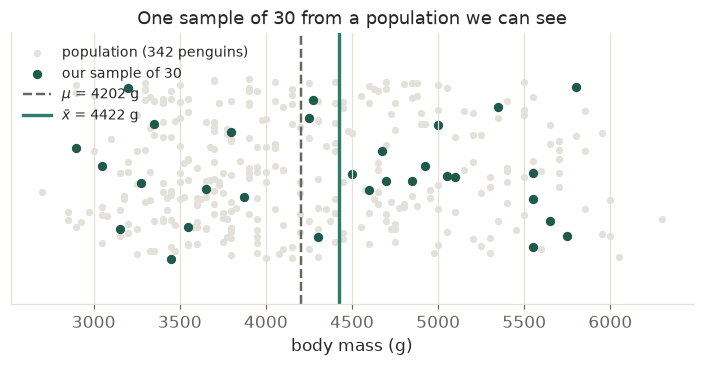

In [7]:
pop = penguins.dropna(subset=["body_mass_g"]).reset_index(drop=True)
picked = pop.sample(30, random_state=1)

fig, ax = plt.subplots(figsize=(8, 3.2))
jitter = rng.uniform(0, 1, len(pop))                       # spread the dots vertically so they do not stack
ax.scatter(pop["body_mass_g"], jitter, s=14, color=C["line"], label="population (342 penguins)")
ax.scatter(picked["body_mass_g"], jitter[picked.index], s=26, color=C["accent_strong"], label="our sample of 30")
ax.axvline(mass.mean(), color=C["ink_soft"], ls="--", lw=1.6, label=rf"$\mu$ = {mass.mean():.0f} g")
ax.axvline(picked["body_mass_g"].mean(), color=C["accent"], lw=2.2, label=rf"$\bar{{x}}$ = {picked['body_mass_g'].mean():.0f} g")

ax.set_yticks([]); ax.set_ylim(-0.25, 1.25); ax.grid(axis="y", visible=False)
ax.set_xlabel("body mass (g)"); ax.set_title("One sample of 30 from a population we can see")
ax.legend(loc="upper left", fontsize=9)
plt.show()

In [ ]:
# Your turn.
# 1. Draw a sample of 30 with random_state=7 and print its mean.
# 2. Draw a sample of 100 with random_state=7 and print its mean.
# Which one lands closer to mu? Is that guaranteed, or did you just get lucky?

pop = penguins.dropna(subset=["body_mass_g"])

small = ...   # replace with pop.sample(...)
large = ...

# print(f"n=30  xbar = {small['body_mass_g'].mean():.1f}")
# print(f"n=100 xbar = {large['body_mass_g'].mean():.1f}")
# print(f"mu          = {pop['body_mass_g'].mean():.1f}")

## 1.2 Sampling methods and bias

*How* you pick matters more than how many you pick. Three ways to choose thirty penguins.

A **simple random sample** gives every penguin the same chance. A **stratified sample** splits the
population into groups first, here by species, and takes a fair share from each. A **convenience
sample** takes whatever is easy to reach, which on this project would be the birds on the nearest
island.

Look at where the species actually live before you guess which method gets into trouble.

In [8]:
pd.crosstab(penguins["island"], penguins["species"])

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


Torgersen has nothing but Adelie penguins, and Biscoe is mostly Gentoo. Since Gentoo are much the
heaviest species, a researcher who only works on one island is not collecting a small sample of all
penguins. They are collecting a perfect sample of the wrong population.

In [9]:
penguins.groupby("species")["body_mass_g"].agg(["count", "mean"]).round(0)

,count,mean
species,,
Adelie,151,3701.0
Chinstrap,68,3733.0
Gentoo,123,5076.0


In [10]:
pop = penguins.dropna(subset=["body_mass_g"])
mu = pop["body_mass_g"].mean()

def simple(n, seed):
    return pop.sample(n, random_state=seed)["body_mass_g"].mean()

def stratified(n, seed):
    # take a share from each species, proportional to how common that species is
    parts = []
    for species, group in pop.groupby("species"):
        share = max(1, round(n * len(group) / len(pop)))
        parts.append(group.sample(share, random_state=seed))
    return pd.concat(parts)["body_mass_g"].mean()

def convenience(n, seed):
    # only the birds on the island nearest the hut
    return pop[pop["island"] == "Torgersen"].sample(n, random_state=seed)["body_mass_g"].mean()

rows = []
for seed in range(200):
    rows.append({"simple": simple(30, seed), "stratified": stratified(30, seed), "convenience": convenience(30, seed)})
methods = pd.DataFrame(rows)

(methods.mean() - mu).round(1).rename("average error (g) over 200 samples").to_frame()

,average error (g) over 200 samples
simple,8.3
stratified,15.9
convenience,-498.0


Simple and stratified random sampling are off by a few grams in either direction, which is just
noise. Convenience sampling is off by hundreds of grams, in the same direction, every single time.

That is the difference between **variance** and **bias**. Variance shrinks when you collect more
data. Bias does not. A convenience sample of three thousand Torgersen penguins would be just as
wrong as a sample of thirty, only more confidently.

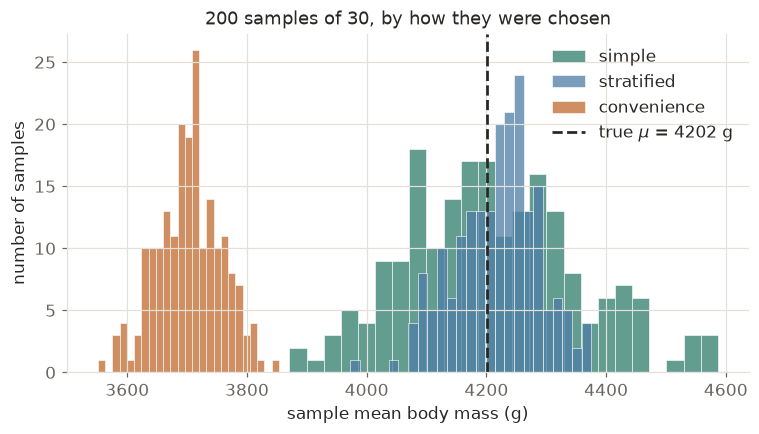

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
colours = [C["accent"], C["cat3"], C["warn"]]
for (name, col), colour in zip(methods.items(), colours):
    ax.hist(col, bins=25, alpha=0.75, color=colour, label=name, edgecolor="white", linewidth=0.5)
ax.axvline(mu, color=C["ink"], ls="--", lw=1.8, label=rf"true $\mu$ = {mu:.0f} g")

ax.set_xlabel("sample mean body mass (g)"); ax.set_ylabel("number of samples")
ax.set_title("200 samples of 30, by how they were chosen")
ax.legend()
plt.show()

In [ ]:
# Your turn.
# Build a fourth sampler: a "volunteer" sample that only catches the penguins that are easiest
# to grab, which we will say are the 80 lightest birds. Run it 200 times and find its average error.
# Before you run it, write down whether you expect the error to be positive or negative, and why.

def volunteer(n, seed):
    easiest = pop.nsmallest(80, "body_mass_g")
    ...   # sample n from easiest and return the mean body mass

# errors = [volunteer(30, s) - mu for s in range(200)]
# print(f"average error: {np.mean(errors):+.1f} g")

## 1.3 Variation in samples

Back to honest sampling. If a single sample mean is a guess, how far off is a guess usually? Draw a
thousand samples and look at the spread of the answers.

In [12]:
def many_means(n, reps=1000):
    return np.array([pop["body_mass_g"].sample(n, random_state=s).mean() for s in range(reps)])

means_10 = many_means(10)
means_40 = many_means(40)

for n, m in [(10, means_10), (40, means_40)]:
    print(f"n = {n:3d}   mean of the sample means = {m.mean():7.1f} g   sd of them = {m.std(ddof=1):6.1f} g")
print(f"        the population mean is {mu:.1f} g")

n =  10   mean of the sample means =  4220.5 g   sd of them =  248.4 g
n =  40   mean of the sample means =  4203.3 g   sd of them =  123.0 g
        the population mean is 4201.8 g


Two things to notice. The sample means centre on the truth, at both sizes. And the spread of those
means shrinks as $n$ grows, which is what "a bigger sample is more trustworthy" actually means.

How much does it shrink? There is a formula, and you can check it right now.

In [13]:
sigma = pop["body_mass_g"].std(ddof=0)

for n, m in [(10, means_10), (40, means_40)]:
    print(f"n = {n:3d}   observed sd of sample means = {m.std(ddof=1):6.1f} g"
          f"   formula sigma/sqrt(n) = {sigma / np.sqrt(n):6.1f} g")

n =  10   observed sd of sample means =  248.4 g   formula sigma/sqrt(n) =  253.2 g
n =  40   observed sd of sample means =  123.0 g   formula sigma/sqrt(n) =  126.6 g


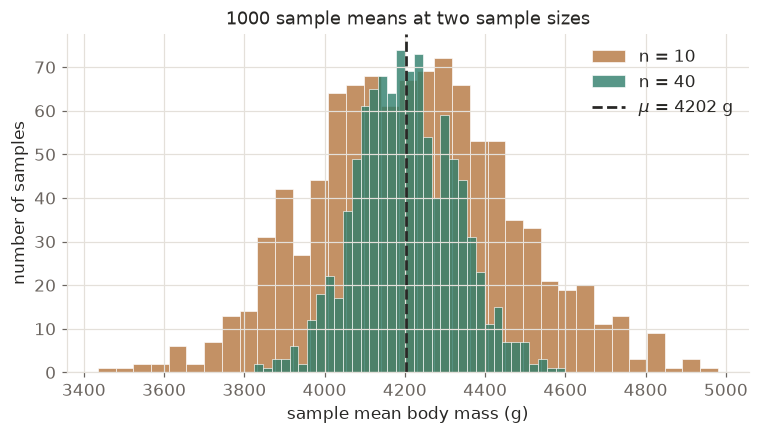

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(means_10, bins=35, alpha=0.8, color=C["cat2"], label="n = 10", edgecolor="white", linewidth=0.5)
ax.hist(means_40, bins=35, alpha=0.8, color=C["accent"], label="n = 40", edgecolor="white", linewidth=0.5)
ax.axvline(mu, color=C["ink"], ls="--", lw=1.8, label=rf"$\mu$ = {mu:.0f} g")

ax.set_xlabel("sample mean body mass (g)"); ax.set_ylabel("number of samples")
ax.set_title("1000 sample means at two sample sizes")
ax.legend()
plt.show()

In [ ]:
# Your turn.
# The formula says the spread of sample means falls like 1/sqrt(n), so going from n=10 to n=40
# should halve it. Check that, then find the n you would need to halve it again.

for n in [10, 40, ...]:
    ...   # print n, the observed sd of 1000 sample means, and sigma/sqrt(n)

## Exercises

Work these in new cells below. There is no answer key, on purpose. Check yourself by computing the
same thing two different ways, which is what a statistician does anyway.

1. **Flipper length.** Redo section 1.1 for `flipper_length_mm` instead of body mass. Is a sample of
   30 flippers proportionally more or less accurate than a sample of 30 weights? Compare
   $\sigma/\mu$ for the two measurements before you look, and see whether that predicts it.

2. **A biased sample that looks fine.** Find a way of picking 30 penguins that gives roughly the
   right mean body mass but the wrong answer for something else. Sampling only Biscoe island is a
   start. What question would that sample answer badly?

3. **Sex, which is missing eleven times.** Eleven penguins have no recorded sex. Compare the mean
   body mass of the birds with a recorded sex against the eleven without. If the missing ones look
   different, dropping them is itself a sampling decision. Are they different here?

4. **How small is too small.** Draw 1000 samples at $n = 2, 5, 10, 25, 50, 100$ and plot the standard
   deviation of the sample means against $n$. Then plot it against $1/\sqrt{n}$. One of those two
   plots is a straight line. Which, and why?

5. **Your own data.** Load `data/cars.csv` and treat the 398 cars as a population. Which sampling
   method would a car magazine be using if it only reviewed cars it was lent by manufacturers?
   Simulate it and measure the bias in `mpg`.

## What you should take away

A sample is a guess about a population, and an honest guess is still wrong most of the time. That
wrongness has two very different causes. **Variance** is the luck of the draw, it points in a random
direction, and more data fixes it. **Bias** comes from how you chose, it points the same way every
time, and more data makes it worse rather than better.

The spread of sample means around the truth is $\sigma/\sqrt{n}$, which you verified rather than
took on faith. That quantity comes back in Chapter 7 with a name, the standard error, and it is the
engine inside every confidence interval and every test in the rest of the course.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*